In [1]:
import matplotlib.pyplot as plt
import numpy as np
from pyiron_base import Project

In [2]:
from pyiron_glass import (
    melt_quench_simulation,
    generate_potential,
    get_ase_structure,
    get_structure_dict,
)

In [3]:
pr = Project("test")
atoms_dict = get_structure_dict(
    comp="0.25CaO-0.25Al2O3-0.50SiO2", 
    n_molecules=100, 
    density=2.69*1.0, 
    min_distance=1.8, 
    max_attempts_per_atom = 10000,
    pyiron_project=pr,
)
structure = get_ase_structure(atoms_dict=atoms_dict, pyiron_project=pr,)
potential = generate_potential(atoms_dict=atoms_dict, pyiron_project=pr,)

In [4]:
delayed = melt_quench_simulation(
    structure=structure, 
    potential=potential,
    temperature_high=5000,
    temperature_low=300,
    n_print=1000,
    working_directory="lmp_tmp_directory",
    heating_rate=int(1e14),
    cooling_rate=int(1e14),
    pyiron_project=pr,
)

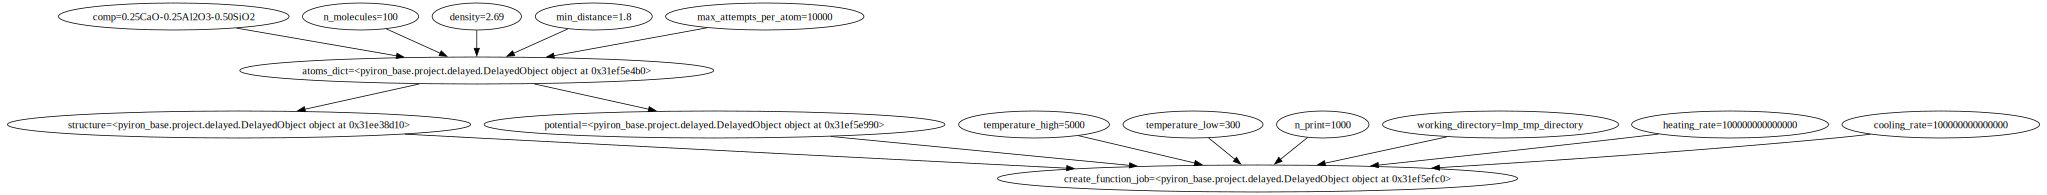

In [5]:
delayed.draw()

In [10]:
result = delayed.pull()

In [11]:
# NBVAL_CHECK_OUTPUT
print(f"{np.mean(result["temperature"]):.1f} K")

299.5 K


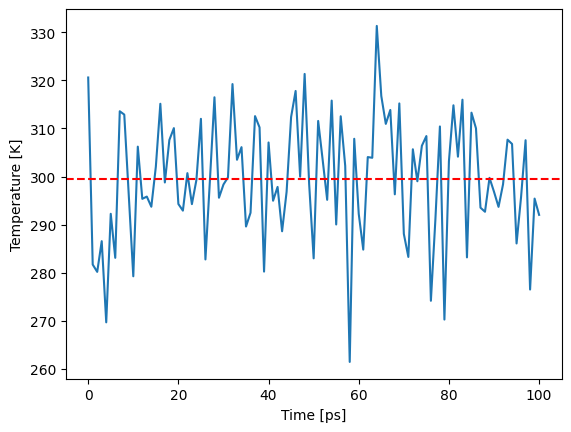

In [12]:
plt.plot(result["steps"]*1e-3, result["temperature"])
plt.axhline(np.mean(result["temperature"]), color="red", linestyle="--")
plt.xlabel("Time [ps]")
plt.ylabel("Temperature [K]");

In [13]:
print(result["structure"])

Atoms(symbols='Al50Ca25O200Si50', pbc=True, cell=[[16.02379173218796, 2.94352278825417e-15, 2.9435227882541704e-15], [-1.962348525357297e-15, 16.023791731, 2.9435227880359454e-15], [-1.9623485253572967e-15, -1.962348525357297e-15, 16.023791731]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)
